# EDA: Contrast Enhancement & Binarization

An **aligned M2 training page** (`train-00460_p01.jpg`) is used to create a controlled **simulated low-contrast, unevenly lit input**. Both rows start with exactly the same input. The top row applies CLAHE before Otsu; the bottom row sends the input directly to Otsu. This illustrates what can change when CLAHE is skipped. The first image is simulated degradation of a real page, not an untouched dataset image. No rotation is applied.

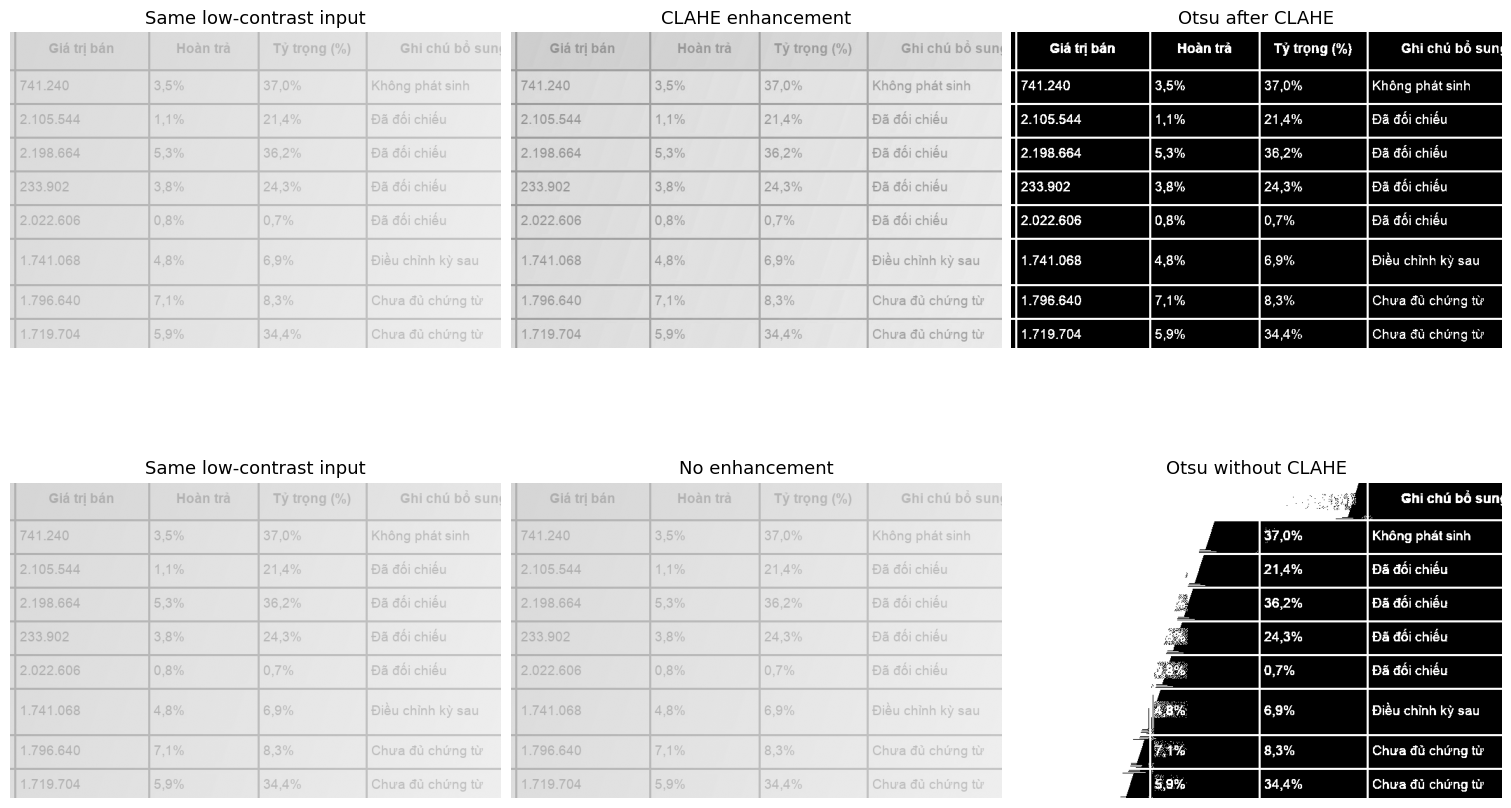

Otsu thresholds: with CLAHE = 197, without CLAHE = 225


In [6]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

relative_image = Path("data/training_set/images/train-00460_p01.jpg")
image_path = next(
    (root / relative_image for root in (Path.cwd(), Path.cwd().parent, Path.cwd() / "Doc2Table")
     if (root / relative_image).is_file()),
    None,
)
if image_path is None:
    raise FileNotFoundError(f"Training image not found: {relative_image}")

gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if gray is None:
    raise ValueError(f"Could not read: {image_path}")
height, width = gray.shape
horizontal_light = np.linspace(-22, 22, width, dtype=np.float32)[None, :]
vertical_light = np.linspace(-10, 10, height, dtype=np.float32)[:, None]
low_contrast = np.clip(
    180 + 0.20 * gray.astype(np.float32) + horizontal_light + vertical_light,
    0, 255,
).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(low_contrast)
otsu_with_clahe, binary_with_clahe = cv2.threshold(
    clahe, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
otsu_without_clahe, binary_without_clahe = cv2.threshold(
    low_contrast, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

x0, y0, x1, y1 = 620, 600, 1320, 1050
crop = lambda image: image[y0:y1, x0:x1]
views = (
    (crop(low_contrast), crop(clahe), crop(binary_with_clahe)),
    (crop(low_contrast), crop(low_contrast), crop(binary_without_clahe)),
)
labels = (
    ("Same low-contrast input", "CLAHE enhancement", "Otsu after CLAHE"),
    ("Same low-contrast input", "No enhancement", "Otsu without CLAHE"),
)
fig, axes = plt.subplots(2, 3, figsize=(15, 9), layout="constrained")
for row in range(2):
    for col in range(3):
        axes[row, col].imshow(views[row][col], cmap="gray", vmin=0, vmax=255)
        axes[row, col].set_title(labels[row][col], fontsize=13)
        axes[row, col].axis("off")
plt.show()
print(f"Otsu thresholds: with CLAHE = {otsu_with_clahe:.0f}, "
      f"without CLAHE = {otsu_without_clahe:.0f}")

**How to read:** both Otsu outputs use `THRESH_BINARY_INV`: pixels at or below the chosen threshold become white (255), and brighter pixels become black (0). Otsu classifies brightness, not semantic text. A dark title band can therefore become white while its light text becomes black. The contrast difference here is deliberately simulated; this is a visual comparison, not an accuracy benchmark on the private test.

## From grayscale to binary: why threshold?

This figure uses the CLAHE result from the previous cell. Otsu selected one threshold **on the full page**; the panels show a crop to make the decision visible. For this inverted output, pixels at or below `T` become **255 (white)** and pixels above `T` become **0 (black)**. Dark marks on light cells usually follow the intended foreground/background convention. Dark filled bands and light text can invert that interpretation because thresholding only sees brightness.

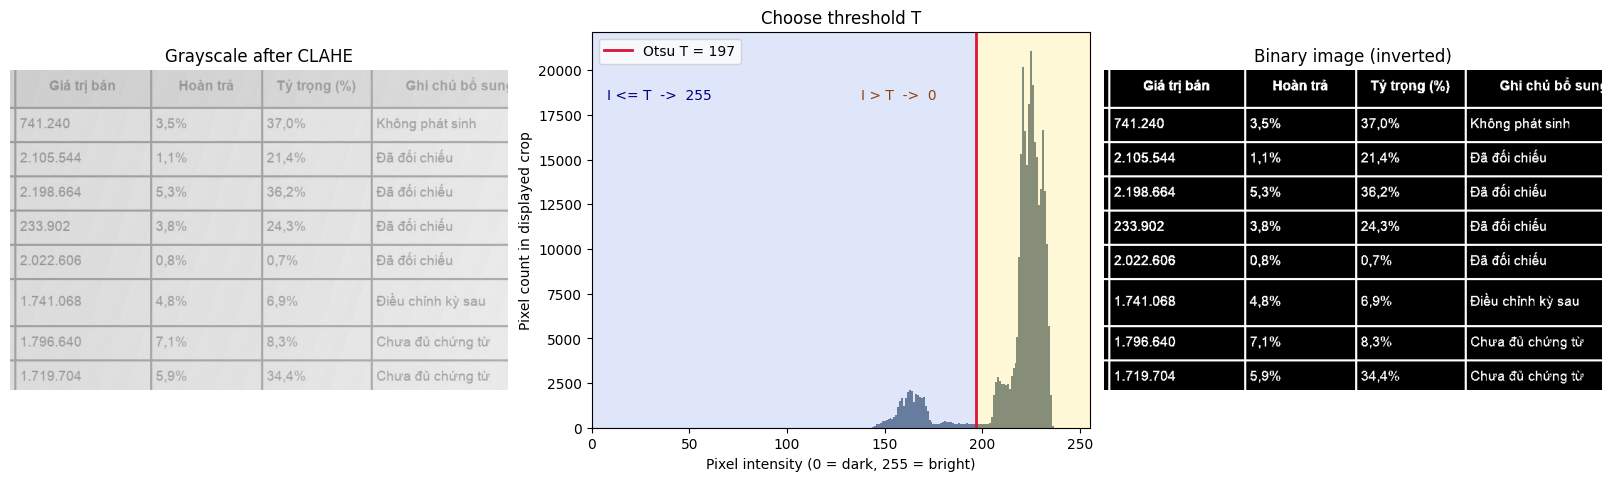

In [7]:
gray_crop = crop(clahe)
binary_crop = crop(binary_with_clahe)
counts, intensities = np.histogram(gray_crop, bins=256, range=(0, 256))
T = otsu_with_clahe

fig, axes = plt.subplots(1, 3, figsize=(16, 4.7), layout="constrained")
axes[0].imshow(gray_crop, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Grayscale after CLAHE")
axes[0].axis("off")

axes[1].bar(intensities[:-1], counts, width=1, color="slategray")
axes[1].axvspan(0, T, color="royalblue", alpha=0.16)
axes[1].axvspan(T, 255, color="gold", alpha=0.16)
axes[1].axvline(T, color="crimson", linewidth=2, label=f"Otsu T = {T:.0f}")
axes[1].set_xlim(0, 255)
axes[1].set_xlabel("Pixel intensity (0 = dark, 255 = bright)")
axes[1].set_ylabel("Pixel count in displayed crop")
axes[1].set_title("Choose threshold T")
axes[1].legend(loc="upper left")
axes[1].text(0.03, 0.83, "I <= T  ->  255", transform=axes[1].transAxes,
             color="navy", fontsize=10)
axes[1].text(0.54, 0.83, "I > T  ->  0", transform=axes[1].transAxes,
             color="saddlebrown", fontsize=10)

axes[2].imshow(binary_crop, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Binary image (inverted)")
axes[2].axis("off")
plt.show()